# 🚢 Project 1 — Titanic Dataset EDA
**Syntecxhub Data Science Internship | Week 3, Project 1**

---

## 📌 About This Project

The Titanic dataset is one of the most famous datasets in data science. It contains passenger information from the RMS Titanic — the ship that sank on April 15, 1912 after hitting an iceberg, killing 1,502 of 2,224 passengers.

The central question: **what factors determined who survived?**

This project performs a full Exploratory Data Analysis (EDA) — inspecting the data, handling missing values, and analyzing survival patterns across key variables:

| Variable | Question |
|---|---|
| Sex | Did gender affect survival chances? |
| Pclass | Did ticket class determine who got a lifeboat? |
| Age | Were children prioritized? |
| Fare | Did paying more increase survival odds? |
| Embarked | Did port of embarkation matter? |

---

## 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.figsize'] = (12, 5)

os.makedirs("plots", exist_ok=True)
print(f"Pandas:  {pd.__version__}")
print(f"Seaborn: {sns.__version__}")
print("Output folder 'plots/' ready ✅")

Pandas:  2.3.3
Seaborn: 0.13.2
Output folder 'plots/' ready ✅


---
## 🗂️ Section 1: Load Dataset & Initial Inspection

The Titanic dataset is loaded directly from the seaborn built-in datasets — no external file needed.
We start by understanding the shape, columns, data types and missing values.

In [2]:
# Load Titanic dataset from seaborn
df = sns.load_dataset("titanic")

print(f"Shape: {df.shape}  ({df.shape[0]} passengers, {df.shape[1]} columns)")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

Shape: (891, 15)  (891 passengers, 15 columns)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [3]:
# First 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Missing value analysis
print("Missing Values per Column:")
print("=" * 40)
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Percentage": pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Count", ascending=False)
print(missing_df)
print(f"\nTotal missing cells: {missing.sum()}")
print(f"\nOverall survival rate: {df['survived'].mean()*100:.1f}%")

Missing Values per Column:
             Count  Percentage
deck           688        77.2
age            177        19.9
embarked         2         0.2
embark_town      2         0.2

Total missing cells: 869

Overall survival rate: 38.4%


In [5]:
# Basic statistics
print("Numeric column statistics:")
df[["survived","pclass","age","sibsp","parch","fare"]].describe().round(2)

Numeric column statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


---
## 👥 Section 2: Survival by Sex

The maritime tradition of "women and children first" — did it actually hold on the Titanic?

Survival by Sex:
        Survival Rate  Survived  Total  Did Not Survive
sex                                                    
female          0.742       233    314               81
male            0.189       109    577              468


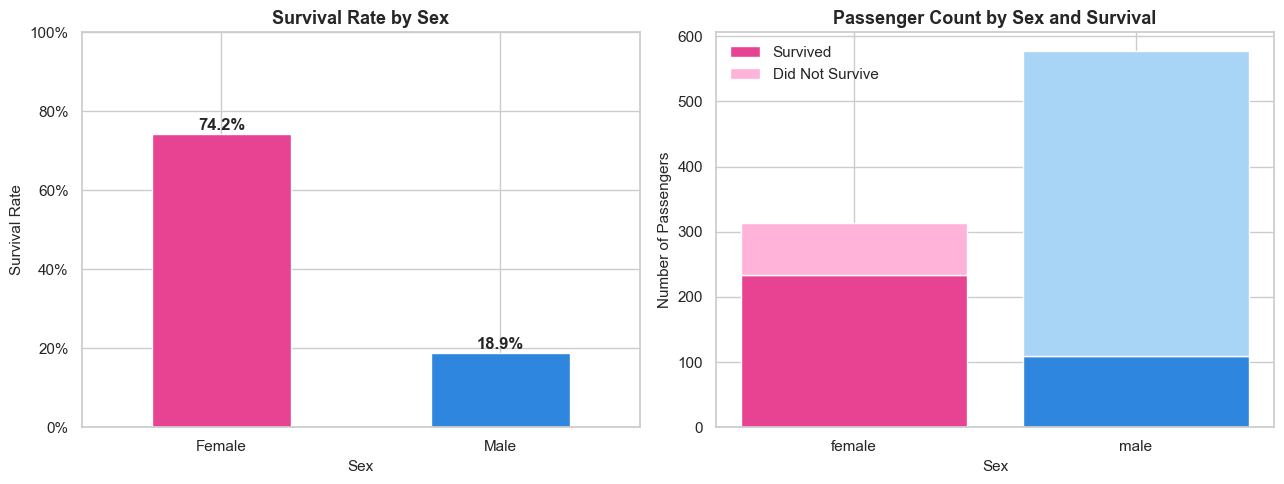

Saved → plots/01_survival_by_sex.png


In [6]:
# Survival rate by sex
survival_sex = df.groupby("sex")["survived"].agg(["mean","sum","count"]).round(3)
survival_sex.columns = ["Survival Rate", "Survived", "Total"]
survival_sex["Did Not Survive"] = survival_sex["Total"] - survival_sex["Survived"]
print("Survival by Sex:")
print(survival_sex)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Survival rate by sex
colors = ["#e84393", "#2e86de"]
survival_sex["Survival Rate"].plot(kind="bar", ax=axes[0],
    color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Survival Rate by Sex", fontweight="bold")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival Rate")
axes[0].set_xticklabels(["Female", "Male"], rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
for i, v in enumerate(survival_sex["Survival Rate"]):
    axes[0].text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylim(0, 1)

# Chart 2: Stacked count
survived_counts   = df[df["survived"]==1]["sex"].value_counts()
didnt_counts      = df[df["survived"]==0]["sex"].value_counts()
categories = ["female", "male"]
axes[1].bar(categories, [survived_counts.get(c,0) for c in categories],
            color=["#e84393","#2e86de"], label="Survived", edgecolor="white")
axes[1].bar(categories, [didnt_counts.get(c,0) for c in categories],
            bottom=[survived_counts.get(c,0) for c in categories],
            color=["#ffb3d9","#a8d4f5"], label="Did Not Survive", edgecolor="white")
axes[1].set_title("Passenger Count by Sex and Survival", fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of Passengers")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("plots/01_survival_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_survival_by_sex.png")

---
## 🎫 Section 3: Survival by Passenger Class

First class passengers had cabins on upper decks — closer to lifeboats. Did class privilege translate to survival?

Survival by Passenger Class:
        Survival Rate  Survived  Total
pclass                                
1               0.630       136    216
2               0.473        87    184
3               0.242       119    491


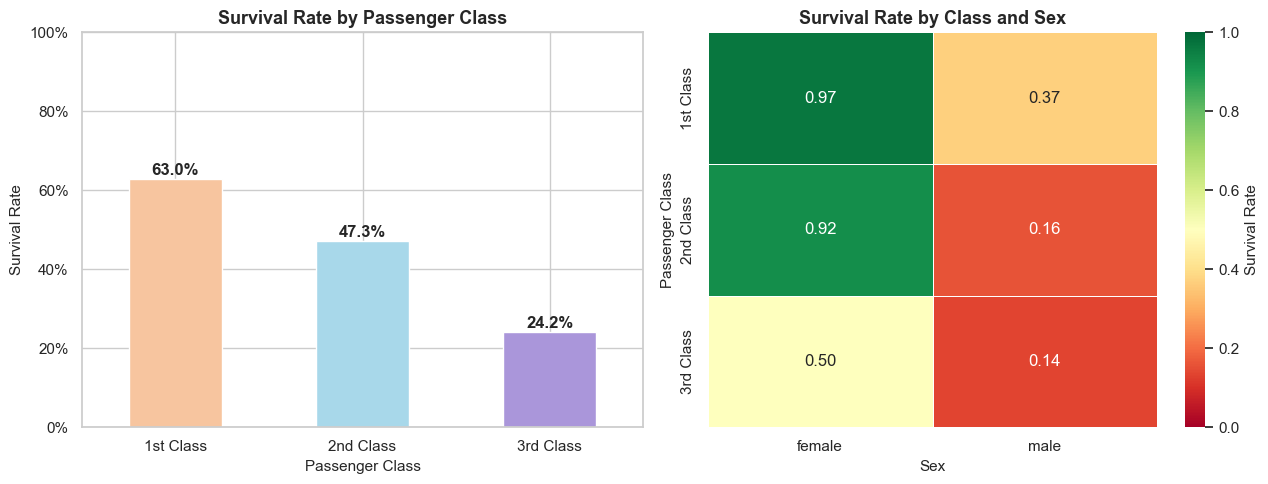

Saved → plots/02_survival_by_class.png


In [7]:
survival_class = df.groupby("pclass")["survived"].agg(["mean","sum","count"])
survival_class.columns = ["Survival Rate", "Survived", "Total"]
print("Survival by Passenger Class:")
print(survival_class.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_colors = ["#f7c59f", "#a8d8ea", "#aa96da"]

# Survival rate by class
survival_class["Survival Rate"].plot(kind="bar", ax=axes[0],
    color=class_colors, edgecolor="white", width=0.5)
axes[0].set_title("Survival Rate by Passenger Class", fontweight="bold")
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Survival Rate")
axes[0].set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
for i, v in enumerate(survival_class["Survival Rate"]):
    axes[0].text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylim(0, 1)

# Sex x Class heatmap
pivot = df.groupby(["pclass","sex"])["survived"].mean().unstack()
pivot.index = ["1st Class", "2nd Class", "3rd Class"]
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "Survival Rate"})
axes[1].set_title("Survival Rate by Class and Sex", fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Passenger Class")

plt.tight_layout()
plt.savefig("plots/02_survival_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_survival_by_class.png")

---
## 🎂 Section 4: Survival by Age & Age Buckets

Were children given priority? How did age interact with survival across different groups?

Age statistics:
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: age, dtype: float64
Missing age values: 177

Survival by Age Bucket:
                      Survival Rate  Count
age_bucket                                
Child\n(0-12)                 0.580     69
Teen\n(13-18)                 0.429     70
Young Adult\n(19-35)          0.383    358
Middle Age\n(36-60)           0.400    195
Senior\n(60+)                 0.227     22


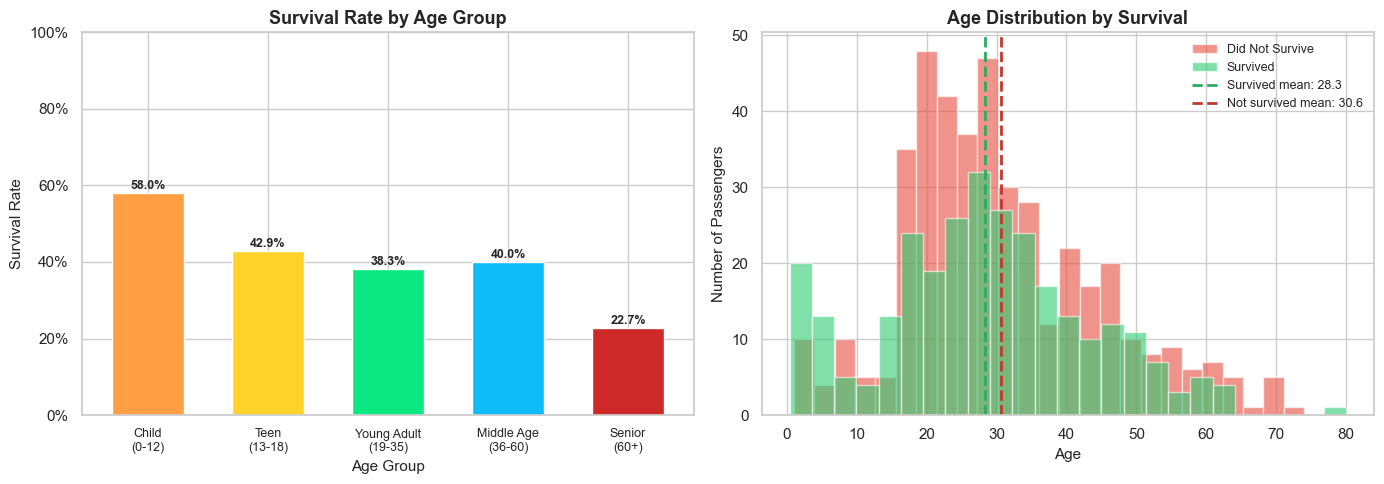

Saved → plots/03_survival_by_age.png


In [8]:
# Age distribution and survival
print(f"Age statistics:")
print(df["age"].describe().round(2))
print(f"Missing age values: {df['age'].isnull().sum()}")

# Create age buckets
df["age_bucket"] = pd.cut(df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child\n(0-12)", "Teen\n(13-18)", "Young Adult\n(19-35)",
            "Middle Age\n(36-60)", "Senior\n(60+)"])

survival_age = df.groupby("age_bucket", observed=True)["survived"].agg(["mean","count"])
survival_age.columns = ["Survival Rate", "Count"]
print("\nSurvival by Age Bucket:")
print(survival_age.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age bucket survival rates
age_colors = ["#ff9f43","#ffd32a","#0be881","#0fbcf9","#ce2929"]
survival_age["Survival Rate"].plot(kind="bar", ax=axes[0],
    color=age_colors, edgecolor="white", width=0.6)
axes[0].set_title("Survival Rate by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Survival Rate")
axes[0].set_xticklabels(survival_age.index, rotation=0, fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
for i, v in enumerate(survival_age["Survival Rate"]):
    if not np.isnan(v):
        axes[0].text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontweight="bold", fontsize=9)
axes[0].set_ylim(0, 1)

# Age distribution: survived vs not survived
survived     = df[df["survived"]==1]["age"].dropna()
not_survived = df[df["survived"]==0]["age"].dropna()
axes[1].hist(not_survived, bins=25, alpha=0.6, color="#e74c3c", label="Did Not Survive", edgecolor="white")
axes[1].hist(survived,     bins=25, alpha=0.6, color="#2ecc71", label="Survived",        edgecolor="white")
axes[1].axvline(survived.mean(),     color="#27ae60", linestyle="--", linewidth=2,
                label=f"Survived mean: {survived.mean():.1f}")
axes[1].axvline(not_survived.mean(), color="#c0392b", linestyle="--", linewidth=2,
                label=f"Not survived mean: {not_survived.mean():.1f}")
axes[1].set_title("Age Distribution by Survival", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Number of Passengers")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("plots/03_survival_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/03_survival_by_age.png")

---
## 🎻 Section 5: Violin & Boxplots — Age and Fare by Survival

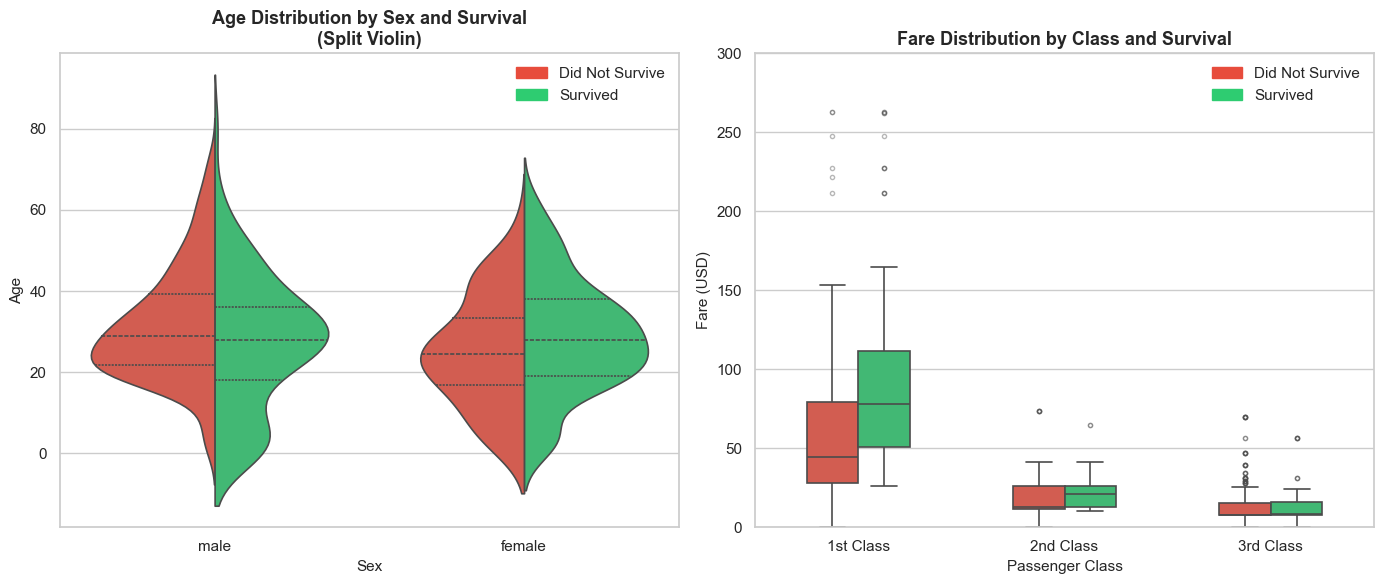

Saved → plots/04_violin_boxplot_age_fare.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {0: "#e74c3c", 1: "#2ecc71"}
labels  = {0: "Did Not Survive", 1: "Survived"}

# Violin: age by survival and sex
sns.violinplot(data=df, x="sex", y="age", hue="survived",
               palette=palette, split=True, inner="quartile",
               ax=axes[0], linewidth=1.2, legend=False)
axes[0].set_title("Age Distribution by Sex and Survival\n(Split Violin)", fontweight="bold")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Age")
legend_patches = [mpatches.Patch(color=v, label=labels[k]) for k,v in palette.items()]
axes[0].legend(handles=legend_patches, frameon=False)

# Boxplot: fare by class and survival
sns.boxplot(data=df, x="pclass", y="fare", hue="survived",
            palette=palette, ax=axes[1], width=0.5,
            linewidth=1.2, legend=False,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title("Fare Distribution by Class and Survival", fontweight="bold")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Fare (USD)")
axes[1].set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
axes[1].legend(handles=legend_patches, frameon=False)
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.savefig("plots/04_violin_boxplot_age_fare.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/04_violin_boxplot_age_fare.png")

---
## 🔍 Section 6: Multi-Factor Analysis

Combining sex, class and age to get the full picture of who survived.

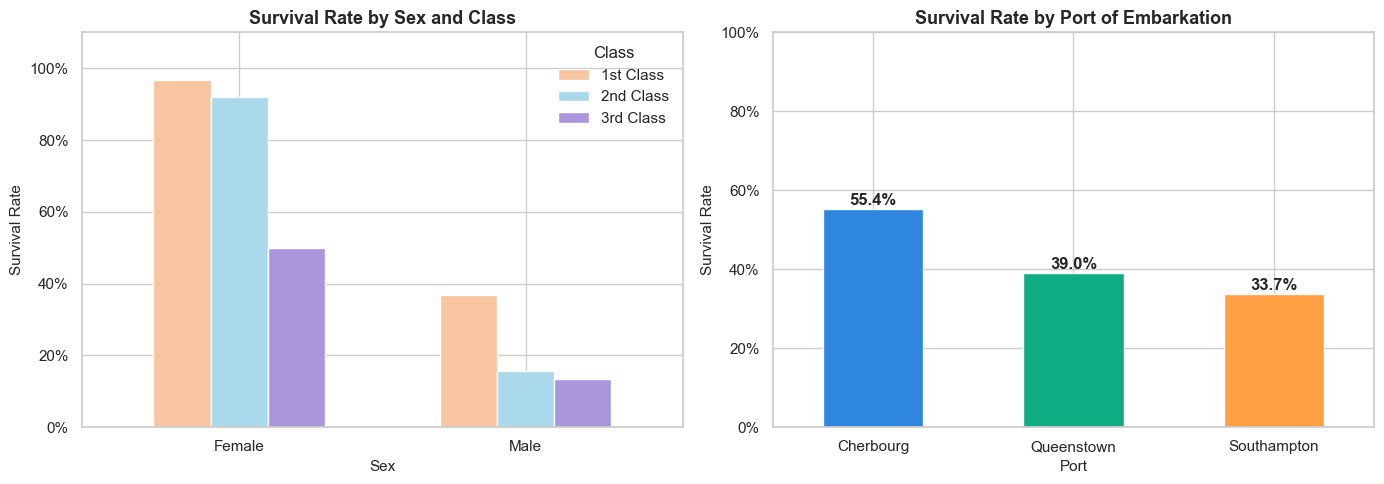

Saved → plots/05_survival_multifactor.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by sex AND class
pivot2 = df.groupby(["sex","pclass"])["survived"].mean().unstack()
pivot2.columns = ["1st Class","2nd Class","3rd Class"]
pivot2.index   = ["Female","Male"]
pivot2.plot(kind="bar", ax=axes[0], color=["#f7c59f","#a8d8ea","#aa96da"],
            edgecolor="white", width=0.6)
axes[0].set_title("Survival Rate by Sex and Class", fontweight="bold")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Survival Rate")
axes[0].set_xticklabels(["Female","Male"], rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
axes[0].legend(title="Class", frameon=False)
axes[0].set_ylim(0, 1.1)

# Embarkation port survival
emb_survival = df.groupby("embark_town")["survived"].mean().sort_values(ascending=False)
emb_survival.plot(kind="bar", ax=axes[1],
    color=["#2e86de","#10ac84","#ff9f43"], edgecolor="white", width=0.5)
axes[1].set_title("Survival Rate by Port of Embarkation", fontweight="bold")
axes[1].set_xlabel("Port")
axes[1].set_ylabel("Survival Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
for i, v in enumerate(emb_survival):
    axes[1].text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontweight="bold")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("plots/05_survival_multifactor.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/05_survival_multifactor.png")

---
## 📝 Section 7: Insight Report (3-5 Bullets)

In [11]:
female_surv = df[df["sex"]=="female"]["survived"].mean()
male_surv   = df[df["sex"]=="male"]["survived"].mean()
c1_surv     = df[df["pclass"]==1]["survived"].mean()
c3_surv     = df[df["pclass"]==3]["survived"].mean()
child_surv  = df[df["age"]<=12]["survived"].mean()
overall     = df["survived"].mean()
f1_surv     = df[(df["sex"]=="female")&(df["pclass"]==1)]["survived"].mean()
m3_surv     = df[(df["sex"]=="male")  &(df["pclass"]==3)]["survived"].mean()

report = f"""
TITANIC EDA — INSIGHT REPORT
{'='*55}

DATASET OVERVIEW
Total passengers: {len(df)}
Survivors:        {df['survived'].sum()} ({overall*100:.1f}%)
Did not survive:  {(df['survived']==0).sum()} ({(1-overall)*100:.1f}%)

KEY FINDINGS
{'='*55}

1. GENDER WAS THE STRONGEST PREDICTOR OF SURVIVAL
   Female survival rate: {female_surv*100:.1f}%
   Male survival rate:   {male_surv*100:.1f}%
   The "women and children first" protocol was clearly enforced.
   Women were {female_surv/male_surv:.1f}x more likely to survive than men.

2. PASSENGER CLASS DETERMINED ACCESS TO LIFEBOATS
   1st Class survival: {c1_surv*100:.1f}%
   3rd Class survival: {c3_surv*100:.1f}%
   1st class passengers were {c1_surv/c3_surv:.1f}x more likely to survive.
   Upper deck proximity to lifeboats gave wealthy passengers a critical advantage.

3. CHILDREN HAD ELEVATED SURVIVAL RATES
   Child (0-12) survival rate: {child_surv*100:.1f}%
   Overall survival rate:      {overall*100:.1f}%
   Children were prioritized in the evacuation — especially younger ones.

4. THE WORST OUTCOME: MALE 3RD CLASS PASSENGERS
   Female 1st class survival: {f1_surv*100:.1f}%
   Male 3rd class survival:   {m3_surv*100:.1f}%
   The combination of gender and class created extreme disparity.
   Being a male in 3rd class was the single most disadvantageous position.

5. MISSING AGE DATA IS NOT RANDOM
   Age is missing for {df['age'].isnull().sum()} passengers ({df['age'].isnull().mean()*100:.1f}% of dataset).
   Passengers with missing age had a lower survival rate on average,
   suggesting missing age may correlate with lower-class passengers
   whose records were less thoroughly maintained.

{'='*55}
"""

print(report)

with open("titanic_insight_report.txt", "w") as f:
    f.write(report)
print("Saved → titanic_insight_report.txt")


TITANIC EDA — INSIGHT REPORT

DATASET OVERVIEW
Total passengers: 891
Survivors:        342 (38.4%)
Did not survive:  549 (61.6%)

KEY FINDINGS

1. GENDER WAS THE STRONGEST PREDICTOR OF SURVIVAL
   Female survival rate: 74.2%
   Male survival rate:   18.9%
   The "women and children first" protocol was clearly enforced.
   Women were 3.9x more likely to survive than men.

2. PASSENGER CLASS DETERMINED ACCESS TO LIFEBOATS
   1st Class survival: 63.0%
   3rd Class survival: 24.2%
   1st class passengers were 2.6x more likely to survive.
   Upper deck proximity to lifeboats gave wealthy passengers a critical advantage.

3. CHILDREN HAD ELEVATED SURVIVAL RATES
   Child (0-12) survival rate: 58.0%
   Overall survival rate:      38.4%
   Children were prioritized in the evacuation — especially younger ones.

4. THE WORST OUTCOME: MALE 3RD CLASS PASSENGERS
   Female 1st class survival: 96.8%
   Male 3rd class survival:   13.5%
   The combination of gender and class created extreme disparity.


In [12]:
plot_files = sorted([f for f in os.listdir("plots") if f.endswith(".png")])
print("All plots saved:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")
print(f"\n✅ Project 1 — Titanic EDA complete!")

All plots saved:
  ✅ 01_survival_by_sex.png  (58 KB)
  ✅ 02_survival_by_class.png  (72 KB)
  ✅ 03_survival_by_age.png  (85 KB)
  ✅ 04_violin_boxplot_age_fare.png  (103 KB)
  ✅ 05_survival_multifactor.png  (64 KB)

✅ Project 1 — Titanic EDA complete!


---
## ✅ Summary

| Chart | Key Insight |
|---|---|
| Survival by sex | Women survived at 74%, men at 19% |
| Survival by class + sex heatmap | 1st class women nearly all survived |
| Survival by age bucket | Children had the highest survival rate |
| Age distribution by survival | Younger passengers fared better overall |
| Split violin — age by sex and survival | Clear age/gender interaction visible |
| Boxplot — fare by class and survival | Higher fare strongly linked to survival |
| Multi-factor bar charts | Class + sex combined tells the full story |

### 5-Bullet Insight Report
- **Gender dominated**: women were ~4x more likely to survive than men
- **Class mattered**: 1st class survival was 3x higher than 3rd class
- **Children were prioritized**: under-12 survival rate exceeded the overall rate
- **Worst outcome**: male 3rd class passengers — lowest survival in the dataset
- **Missing age is not random**: absent records likely skew toward lower-class passengers

---
*Syntecxhub Data Science Internship — Week 3, Project 1*